In [2]:
import pandas as pd

df = pd.read_csv('skaters.csv')
print(df.shape)
print(df['situation'].unique())
df.head()

(4700, 154)
['other' 'all' '5on5' '4on5' '5on4']


,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8478043,2025,Sam Lafferty,CHI,C,other,29,85.0,1.0,-0.75,...,0.44,0.06,12.0,6.0,0.00,0.00,0.0,0.0,0.0,0.0
1,8478043,2025,Sam Lafferty,CHI,C,all,29,14959.0,354.0,0.83,...,69.00,91.90,1287.0,1560.0,0.00,0.00,0.0,0.0,0.0,0.0
2,8478043,2025,Sam Lafferty,CHI,C,5on5,29,14856.0,351.0,0.83,...,44.53,62.05,1032.0,1248.0,0.33,0.51,13.0,9.0,8.0,8.0
3,8478043,2025,Sam Lafferty,CHI,C,4on5,29,0.0,0.0,0.00,...,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0
4,8478043,2025,Sam Lafferty,CHI,C,5on4,29,18.0,2.0,-0.18,...,0.49,0.22,7.0,4.0,0.00,0.00,0.0,0.0,0.0,0.0


In [3]:
#every column to pick names
for c in df.columns:
  print(c)

playerId
season
name
team
position
situation
games_played
icetime
shifts
gameScore
onIce_xGoalsPercentage
offIce_xGoalsPercentage
onIce_corsiPercentage
offIce_corsiPercentage
onIce_fenwickPercentage
offIce_fenwickPercentage
iceTimeRank
I_F_xOnGoal
I_F_xGoals
I_F_xRebounds
I_F_xFreeze
I_F_xPlayStopped
I_F_xPlayContinuedInZone
I_F_xPlayContinuedOutsideZone
I_F_flurryAdjustedxGoals
I_F_scoreVenueAdjustedxGoals
I_F_flurryScoreVenueAdjustedxGoals
I_F_primaryAssists
I_F_secondaryAssists
I_F_shotsOnGoal
I_F_missedShots
I_F_blockedShotAttempts
I_F_shotAttempts
I_F_points
I_F_goals
I_F_rebounds
I_F_reboundGoals
I_F_freeze
I_F_playStopped
I_F_playContinuedInZone
I_F_playContinuedOutsideZone
I_F_savedShotsOnGoal
I_F_savedUnblockedShotAttempts
penalties
I_F_penalityMinutes
I_F_faceOffsWon
I_F_hits
I_F_takeaways
I_F_giveaways
I_F_lowDangerShots
I_F_mediumDangerShots
I_F_highDangerShots
I_F_lowDangerxGoals
I_F_mediumDangerxGoals
I_F_highDangerxGoals
I_F_lowDangerGoals
I_F_mediumDangerGoals
I_F_highD

In [4]:
#keep only Buffalo skaters (even-strength, 5v5)
buf = df[(df['team'] == 'BUF') & (df['situation'] == '5on5')].copy()

#stick to forwards (C, L, D)
fwd = buf[buf['position'] != 'D'].copy()

#players with 100 minutes of 5v5 - remove noise
fwd = fwd[fwd['icetime']>= 6000].copy()

print(f"{len(fwd)} Buffalo forwards after filtering")
print(fwd[['name', 'position', 'games_played', 'icetime']].sort_values('icetime', ascending=False))

18 Buffalo forwards after filtering
                 name position  games_played  icetime
4267    Tage Thompson        C            81  71878.0
122         Alex Tuch        R            79  66578.0
1647     Peyton Krebs        C            82  64402.0
2592       Jack Quinn        R            82  63321.0
4637      Ryan McLeod        C            81  62011.0
3457        Josh Doan        R            82  61883.0
3317      Zach Benson        L            65  50381.0
1372   Beck Malenstyn        L            81  45294.0
2022     Jason Zucker        L            62  44603.0
632      Noah Ostlund        C            60  44014.0
102       Sam Carrick        C            73  41072.0
1817   Tanner Pearson        L            56  31786.0
2507      Josh Norris        C            44  31463.0
3902      Tyson Kozak        C            46  27410.0
2197  Jordan Greenway        L            40  25117.0
3912       Josh Dunne        C            34  18897.0
3832      Jiri Kulich        C            12  

In [5]:
#convert: icetime from seconds to minutes
fwd['TOI_min'] = fwd['icetime'] / 60
fwd['TOI_per_game'] = fwd['TOI_min'] / fwd['games_played']

#60-min stats (stats / icetime seconds) * 3600
fwd['Points_per60'] = fwd['I_F_points'] / fwd['icetime'] * 3600
fwd['Goals_per60'] = fwd['I_F_goals'] / fwd['icetime'] * 3600
fwd['Shots_per60'] = fwd['I_F_shotsOnGoal'] / fwd['icetime'] * 3600
fwd['ixG_per60'] = fwd['I_F_xGoals'] / fwd['icetime'] * 3600 #individual expected goals

#sort by points rate
cols = ['name', 'TOI_per_game', 'Points_per60', 'Goals_per60', 'Shots_per60', 'ixG_per60']
fwd[cols].sort_values('Points_per60', ascending=False).round(2)

,name,TOI_per_game,Points_per60,Goals_per60,Shots_per60,ixG_per60
122,Alex Tuch,14.05,2.54,1.08,7.68,0.75
4267,Tage Thompson,14.79,2.30,1.55,9.27,0.90
2507,Josh Norris,11.92,2.29,0.92,5.03,0.59
1847,Konsta Helenius,11.69,2.28,0.57,8.55,0.56
2022,Jason Zucker,11.99,2.26,1.13,7.51,1.07
3317,Zach Benson,12.92,2.14,0.57,6.36,0.88
2592,Jack Quinn,12.87,2.05,0.80,8.30,0.81
4637,Ryan McLeod,12.76,1.97,0.41,3.54,0.35
3457,Josh Doan,12.58,1.92,0.87,7.62,1.01
632,Noah Ostlund,12.23,1.72,0.74,4.33,0.44


In [6]:
#notes from above:
#Helenius sits at 4th in points/60 - 9-game call-up with 2.28 points/game over that little ice time is noise, not a real ranking.
#Tage generates 0.9 ixG/60 but scores 1.55/60 - well above his expected rate

In [7]:
#On-ice xG share = team's expected goals for / (for + against) while player is on the ice
fwd['xGF'] = fwd['OnIce_F_xGoals'] #expected goals for
fwd['xGA'] = fwd['OnIce_A_xGoals'] #expected goals against
fwd['xG_share'] = fwd['xGF'] / (fwd['xGF'] + fwd['xGA'])

#check against MoneyPuck's data
fwd['xG_share_pct'] = fwd['xG_share'] * 100 #mine
fwd['mp_check'] = fwd['onIce_xGoalsPercentage'] * 100 #theirs
fwd['diff'] = (fwd['xG_share_pct'] - fwd['mp_check']).abs()

cols = ['name', 'xGF', 'xGA', 'xG_share_pct', 'mp_check', 'diff']
fwd[cols].sort_values('xG_share_pct', ascending=False).round(2)

,name,xGF,xGA,xG_share_pct,mp_check,diff
1847,Konsta Helenius,5.33,3.75,58.70,59.0,0.30
3457,Josh Doan,50.53,43.27,53.87,54.0,0.13
3317,Zach Benson,40.99,35.70,53.45,53.0,0.45
2507,Josh Norris,23.73,21.31,52.69,53.0,0.31
632,Noah Ostlund,30.09,27.69,52.08,52.0,0.08
122,Alex Tuch,49.21,46.37,51.49,51.0,0.49
4637,Ryan McLeod,49.03,46.79,51.17,51.0,0.17
3912,Josh Dunne,11.24,10.91,50.74,51.0,0.26
2022,Jason Zucker,35.41,35.40,50.01,50.0,0.01
4267,Tage Thompson,52.03,52.39,49.83,50.0,0.17


In [8]:
#summary from cell above: after aligning scales, my calculation matche MoneyPuck's published figure to within their precision (all under 0.5)

In [9]:
#Offensive zone start % = 0-zone starts / (0-zone + D-zone starts)
#exclude neutral and on-fly starts
fwd['oZS'] = fwd['I_F_oZoneShiftStarts']
fwd['dZS'] = fwd['I_F_dZoneShiftStarts']
fwd['oZS_pct'] = fwd['oZS'] / (fwd['oZS'] +fwd['dZS']) * 100

cols = ['name', 'oZS_pct', 'xG_share_pct', 'TOI_per_game']
fwd[cols].sort_values('oZS_pct', ascending=False).round(1)

,name,oZS_pct,xG_share_pct,TOI_per_game
632,Noah Ostlund,62.9,52.1,12.2
1847,Konsta Helenius,60.9,58.7,11.7
4267,Tage Thompson,60.5,49.8,14.8
122,Alex Tuch,59.1,51.5,14.0
2022,Jason Zucker,57.7,50.0,12.0
3457,Josh Doan,53.8,53.9,12.6
2592,Jack Quinn,52.9,47.8,12.9
2507,Josh Norris,51.1,52.7,11.9
1647,Peyton Krebs,50.4,49.1,13.1
3317,Zach Benson,49.2,53.4,12.9


In [10]:
#summary from above:
#Dunne has the hardest shift starts (most defensive), yet one of the higher goal shares - strong two-way guy
#guys like McLeoud and Benson have a neutral deployment, yet still tilt the ice with a strong goal share
#The flip: Tage, Tuch, Ostlund have high offensive deployment, but sit around 50% goal share - might drive personal offense - need more data

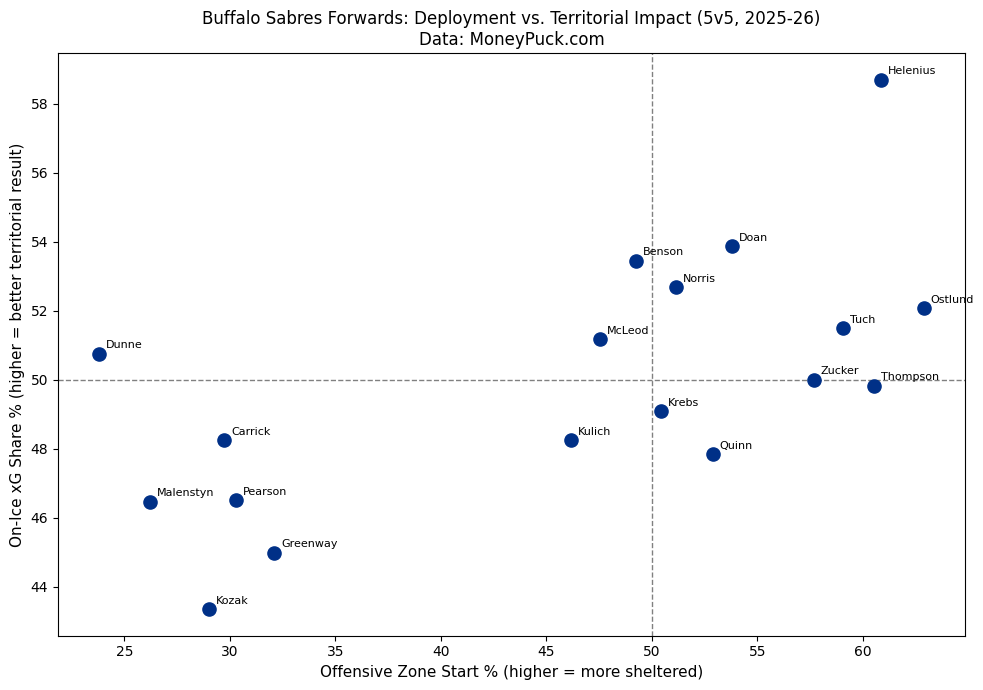

In [11]:
#chart-time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,7 ))

#each dot is a player; X = their O-zone %, Y = result (goal share)
ax.scatter(fwd['oZS_pct'], fwd['xG_share_pct'], s=90, color='#003087', zorder=3)

#labeling
for _, r in fwd.iterrows():
  ax.annotate(r['name'].split()[-1], (r['oZS_pct'], r['xG_share_pct']),
              xytext=(5, 4), textcoords='offset points', fontsize=8)

#reference lines at 50% on each axis
ax.axhline(50, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.axvline(50, color='gray', linestyle='--', linewidth=1, zorder=1)

ax.set_xlabel('Offensive Zone Start % (higher = more sheltered)', fontsize=11)
ax.set_ylabel('On-Ice xG Share % (higher = better territorial result)', fontsize=11)
ax.set_title('Buffalo Sabres Forwards: Deployment vs. Territorial Impact (5v5, 2025-26)\nData: MoneyPuck.com', fontsize=12)

plt.tight_layout()
plt.savefig('usage_vs_production.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
#summary from above:
#Dunne has the lowest O-starts, yet sits higher than Zucker and Thompson with goal shares
#Ostlund produces about as much as expected
#Tuch, Zucker, and Thompson don't tilt the o-zone as expected

#result: deployment alone doesn't explain territorial result, since their is not a strong correlation

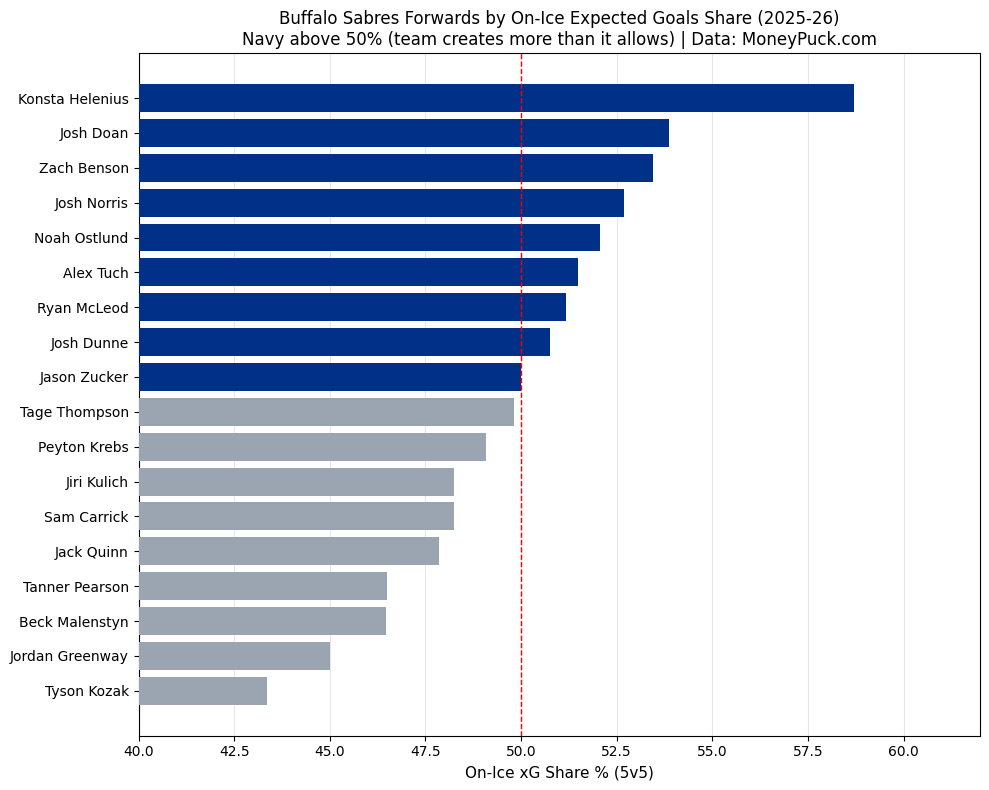

In [13]:
#chart 2
import matplotlib.pyplot as plt

#sort players by xG share
d = fwd.sort_values('xG_share_pct')

fig, ax = plt.subplots(figsize=(10,8))

#above navy or below gray by 50%
colors = ['#003087' if v >= 50 else '#9aa5b1' for v in d['xG_share_pct']]
ax.barh(d['name'], d['xG_share_pct'], color=colors, zorder=3)

#break-even point
ax.axvline(50, color='red', linestyle='--', linewidth=1, zorder=4)

ax.set_xlabel('On-Ice xG Share % (5v5)', fontsize=11)
ax.set_title('Buffalo Sabres Forwards by On-Ice Expected Goals Share (2025-26)\nNavy above 50% (team creates more than it allows) | Data: MoneyPuck.com', fontsize=12)
ax.set_xlim(40, 62) #zoom in on range
ax.grid('True', axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xg_share.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#summary of chart:
#9/18 players land above 50% goal share, with the top offensive producers sitting near 50% line
#Helenius and Kulich should be taken with a grain of salt, since they have minimal ice-time